In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

RANDOMNESS FIX

In [2]:
import random
import numpy as np
import torch

SEED = 42

# Python built-in random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch (CPU)
torch.manual_seed(SEED)

# PyTorch (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make PyTorch deterministic (slower, but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
import os

os.listdir("/content/drive/MyDrive/NIH_Xray")


['archive (3).zip', 'sample', 'sample_labels.csv']

In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/NIH_Xray/archive (3).zip"
extract_path = "/content/NIH_Xray/"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [5]:
os.listdir("/content/NIH_Xray")


['sample', 'sample_labels.csv']

In [6]:
IMG_DIR = "/content/NIH_Xray/sample/images/"
LABELS_PATH = "/content/NIH_Xray/sample_labels.csv"


In [7]:
import pandas as pd

df = pd.read_csv(LABELS_PATH)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [8]:
df.columns

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth',
       'OriginalImageHeight', 'OriginalImagePixelSpacing_x',
       'OriginalImagePixelSpacing_y'],
      dtype='object')

In [9]:
print("Number of images", len(df))

Number of images 5606


In [10]:
df.shape

(5606, 11)

In [11]:
df.head(3)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168


Labels are string-based

Multiple diseases separated by "|"

"No Finding" = healthy

This is a multi-label classification dataset

Patient ID is available → we must split by patient(since same patient can appear many times even in test and train so splitting by patient helps reduce that)

Create binary target column

In [12]:
df["has_disease"] = (df["Finding Labels"] != "No Finding").astype(int)

In [13]:
df[["Finding Labels", "has_disease"]].head(10)

,Finding Labels,has_disease
0,Emphysema|Infiltration|Pleural_Thickening|Pneu...,1
1,Cardiomegaly|Emphysema,1
2,No Finding,0
3,Atelectasis,1
4,Cardiomegaly|Edema|Effusion,1
5,Consolidation|Mass,1
6,No Finding,0
7,No Finding,0
8,Effusion,1
9,No Finding,0


Check class balance

In [14]:
df["has_disease"].value_counts(normalize=True)

,proportion
has_disease,
0,0.54299
1,0.45701


54.3% images are healthy

45.7% images have disease

This is mild imbalance

dataset is fairly balanced, so:

training will be stable

learning will be easier

metrics will be reliable

Until we know class balance: we

can’t choose metrics

can’t choose loss function

can’t interpret accuracy

can’t judge results

**`Patient-safe train/validation split `**

In [15]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df["Patient ID"]))
train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

In [16]:
set(train_df["Patient ID"]).intersection(set(val_df["Patient ID"]))

set()

“Split my dataframe by patient ID
Give me the row numbers for train and validation
Use those row numbers to create two new dataframes
where no patient appears in both”


df (5606 rows)
│
├── train_idx → row numbers → train_df


│
└── val_idx   → row numbers → val_df


**Image EDA – Level 2**

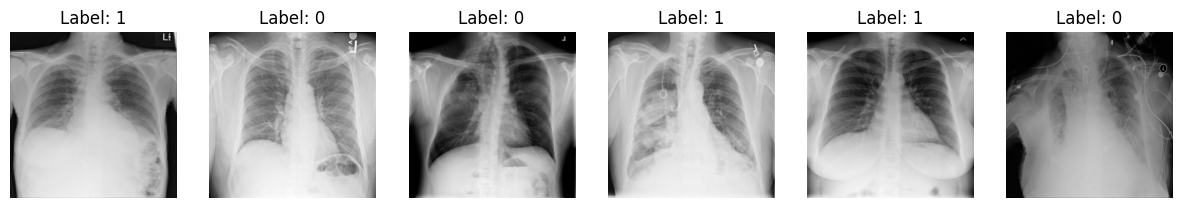

In [17]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

# Updated IMG_DIR path
IMG_DIR = "/content/NIH_Xray/sample/images/"

sample_rows = train_df.sample(6)

plt.figure(figsize=(15,5))

for i, row in enumerate(sample_rows.itertuples()):
  # Use os.path.join for robust path construction
  img_path = os.path.join(IMG_DIR, row._1)
  try:
    img = Image.open(img_path)
    plt.subplot(1,6,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {row.has_disease}")
    plt.axis("off")
  except FileNotFoundError:
    print(f"Warning: Image not found at {img_path}. Skipping this image.")
    # Optionally, you can add a placeholder or break the loop here if many are missing
    continue

plt.show()

THE ABOVE CODE

randomly picks 6 rows from training data

opens corresponding image files

converts to grayscale (X-rays are grayscale)

plots them

shows disease label

**core data pipeline of deep learning**

replacing the transforms (gray to RGB for densenet)

Grayscale(num_output_channels=3)
→ copies the same X-ray into R, G, B

Normalize now needs 3 values, one per channel

In [18]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.Grayscale(num_output_channels=3),  # key line
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # key line
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


**Create a DataLoader and inspect one batch**

A DataLoader answers:

How do I efficiently load many images at once, shuffle them, and send them to the model?

| Component  | Responsibility                           |
| ---------- | ---------------------------------------- |
| Dataset    | How to read **one** sample               |
| DataLoader | How to read **many** samples efficiently |


In [19]:
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import os

class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['Image Index'])
        image = Image.open(img_name).convert('L') # Convert to grayscale if not already
        label = self.df.iloc[idx]['has_disease']

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = ChestXrayDataset(
    train_df,
    img_dir="/content/NIH_Xray/sample/images/",
    transform=train_transforms
)

val_dataset = ChestXrayDataset(
    val_df,
    img_dir="/content/NIH_Xray/sample/images/",
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

**batch_size=8**

The model will see 8 images at once

Small batch = easier debugging

We’ll increase later

**shuffle=True (training only)**

Randomizes image order

Prevents learning sequence patterns

Improves generalization

**shuffle=False (validation)**

Order doesn’t matter

Ensures reproducibility

#### **Inspect ONE batch**



In [20]:
images, labels = next(iter(train_loader))

print("Images batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels", labels)

Images batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8])
Labels tensor([0, 1, 1, 1, 1, 0, 0, 1])


8 → batch size

3 →  channel (X-rays)

224 x 224 → image size

Labels are numeric tensors (model-ready)

0 → No Finding (healthy)

1 → Disease present

8 RGB(GRAY TO RGB) X-ray images, resized and normalized

Why we ALWAYS do this before training

If we skip this:

shape mismatch errors appear later

GPU crashes during training

debugging becomes painful

you won’t know where things broke

**Load a pretrained model**

DenseNet121, commonly used for chest X-rays.

In [21]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(pretrained=True)
# loads a CNN trained on millions of images and has learned visual features


model.classifier = nn.Linear(
    model.classifier.in_features,
                             1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 160MB/s]


Transfer learning means:

Use a model that has already learned how to see
and teach it what to look for

A pretrained CNN already understands:

edges

textures

shapes

anatomical patterns (surprisingly transferable)

We only teach it:

what patterns correspond to “disease vs no disease”

This is standard practice in medical imaging.

In [22]:
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

A long DenseNet architecture

final layer ending with Linear(..., 1)

**Loss function**

Binary Cross Entropy with Logits

In [23]:
criterion = nn.BCEWithLogitsLoss()

Binary classification

Output = 1 number per image

Label = 0 (healthy) or 1 (disease)



“Binary”

Two outcomes:

disease

no disease

2️⃣ “Cross Entropy”

Measures:

how far predicted probability is from true label

Examples:

Predict 0.99 for disease, label = 1 → very good → low loss

Predict 0.01 for disease, label = 1 → very bad → high loss

3️⃣ “With Logits” (important detail)

Your model outputs raw scores, not probabilities.

Accuracy:

doesn’t care how confident the model is

doesn’t penalize dangerous false negatives enough

is not differentiable (can’t train on it)

Loss must be:

smooth

differentiable

sensitive to confidence

That’s why we use BCE loss.

### Optimizer - Adam

(how weights are updated)- Once we know how wrong the model is, we must decide:

“How do we update the weights?”

That’s the optimizer.

In [24]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

**Adam:**

adapts learning rate per parameter

works well with pretrained models

stable for medical datasets

widely used in research

**lr = 1e-4**

This is very important.

Because:

we are fine-tuning a pretrained model

large learning rate would destroy learned features

small learning rate = gentle adjustments

Think of it as:

**“Don’t overwrite what the model already knows — refine it.”**

In [25]:
# Sanity check

print(criterion)
print(optimizer)

BCEWithLogitsLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


**Get ONE batch from the DataLoader**

Right now you have:

data (DataLoader)

a model

a loss function

an optimizer

But learning has not happened yet.

**Learning happens when:**

**we give images to the model (forward pass)**

**the model makes predictions**

**we measure error using the loss function**

**we send that error backward (backward pass)**

**we slightly update the model weights**

We will do this for ONE batch only.

In [26]:
images , labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

What this means (simple terms)

iter(train_loader) → creates an iterator over batches

next(...) → gives the first batch only

.to(device) → moves data to GPU (or CPU)

So now:

images = 8 X-rays

labels = 8 corresponding labels

both live on the same device as the model

**Forward pass (model makes predictions)**

In [27]:
outputs = model(images)
print("outputs Shape:", outputs.shape)

outputs Shape: torch.Size([8, 1])


In [28]:
outputs = model(images)
print("Raw model outputs:", outputs)


Raw model outputs: tensor([[-0.5903],
        [ 0.0118],
        [-0.0633],
        [ 0.1294],
        [ 0.5549],
        [ 0.0707],
        [ 0.1343],
        [-0.0587]], device='cuda:0', grad_fn=<AddmmBackward0>)


Images go into the model

The model applies many layers (CNN filters)

The model outputs raw scores (logits)

These are NOT probabilities

They can be positive or negative

That’s why we used BCEWithLogitsLoss

In [29]:
# Fix tensor shapes

outputs = outputs.squeeze()
print("Outputs shape after squeeze:", outputs.shape)

Outputs shape after squeeze: torch.Size([8])


outputs is [8, 1]

labels is [8]

Loss functions require matching shapes.

squeeze() removes the unnecessary dimension.

**Compute the loss (measure how wrong the model is)**

In [30]:
loss = criterion(outputs, labels.float()) # Cast labels to float
print("Loss value:", loss.item())

Loss value: 0.6522973775863647


The loss is a single number

It summarizes how wrong the model is on this batch

Higher loss → worse predictions

Lower loss → better predictions


At the start, this loss will be:

not very small

not very meaningful yet

**Backward pass**

In [31]:
optimizer.zero_grad()   # clear old gradients
loss.backward()         # compute new gradients
optimizer.step()        # update model weights


This is the heart of deep learning

Let’s break it down clearly:

optimizer.zero_grad()

Clears old gradient values

Prevents mixing gradients from previous steps

loss.backward()

Computes how each weight contributed to the error

Stores gradients inside the model

optimizer.step()

Uses gradients to slightly adjust weights

This is where learning actually happens

After this line:

The model is different than it was before

**Mental model to lock this in**

Images → Model → Outputs

Outputs + Labels → Loss

Loss → Backward → Gradients

Gradients → Optimizer →
Updated Model


In [32]:
#Sanity check

outputs_after = model(images).squeeze()
loss_after = criterion(outputs_after, labels.float())

print("Loss before update:", loss.item())
print("Loss after update:", loss_after.item())

Loss before update: 0.6522973775863647
Loss after update: 0.2519177198410034


The loss may:

slightly decrease

or stay similar

**training loop**.

forward → loss → backward → update


In [33]:
num_epoch = 3

In [34]:
for epoch in range(num_epoch):
   print(f"\nEpoch {epoch+1}/{num_epoch}")
   print("-" * 30)

   model.train()
   running_loss = 0.0

   for images, labels in train_loader:

     images = images.to(device)#moves from cpu to gpu or others
     labels = labels.to(device)


     #Forward pass
     outputs = model(images).squeeze()

     #Compute loss
     loss = criterion(outputs, labels.float())

     #Backward pass
     optimizer.zero_grad() #Clears old gradients so they don’t accumulate incorrectly.
     loss.backward() #Calculates gradients: “Which weights caused the error?”
     optimizer.step() #Updates weights: “Adjust weights to reduce future error”

     running_loss += loss.item()

   epoch_loss = running_loss/len(train_loader)
   print(f"Train Loss: {epoch_loss:.4f}")


Epoch 1/3
------------------------------
Train Loss: 0.6358

Epoch 2/3
------------------------------
Train Loss: 0.6070

Epoch 3/3
------------------------------
Train Loss: 0.5875


**model.train()**

Tells PyTorch:

“I am training now”

This:

enables dropout

enables batchnorm updates

**Loop over train_loader**

Each iteration:

loads one batch

not all data at once

memory efficient

**running_loss**

We accumulate loss across batches so we can:

compute average loss per epoch

see learning trend

**images = images.to(device)**

moves a tensor (or a batch of images) from its current location (usually CPU) to a designated, fast-processing device like a GPU (e.g., 'cuda')

What this tells us (in simple, concrete terms)
1️⃣ **Loss is consistently decreasing** ✅

This means:

the optimizer is working

gradients are correct

the model is learning patterns from X-rays

no bugs in the training loop

This is the minimum requirement for a valid ML experiment.

2️⃣ **The decrease is gradual, not dramatic** ✅

This is actually good, especially in medical imaging.

Why?

You are fine-tuning a pretrained model

Learning rate is small (1e-4)

The model is making careful adjustments, not wild jumps

**Validation loss**

On images the model has never trained on, how wrong is it?

In [35]:
model.eval()
val_loss = 0.0

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images).squeeze()
    loss = criterion(outputs, labels.float())

    val_loss += loss.item()

val_loss /= len(val_loader)
print(f"Validation Loss: {val_loss:.4f}")

Validation Loss: 0.6459


**Compute AUC**

In [36]:
from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
  for images,labels in val_loader:
    images = images.to(device)

    outputs = model(images).squeeze()
    probs = torch.sigmoid(outputs) # Convert logits to probabilities

    all_probs.extend(probs.cpu().numpy())
    all_labels.extend(labels.numpy())

  auc = roc_auc_score(all_labels, all_probs)
  print(f"Validation AUC: {auc:.4f}")


Validation AUC: 0.7059


**sigmoid converts raw scores → probabilities** --Returns a new tensor of the same shape as the input, with all values in the range (0, 1).


we collect predictions across all validation batches

AUC measures:

Does the model assign higher scores to diseased cases than healthy ones?

**Validation AUC ≈ 0.70 ✅**

This is the most important number.

Interpretation:

The model ranks diseased X-rays higher than healthy ones ~70% of the time

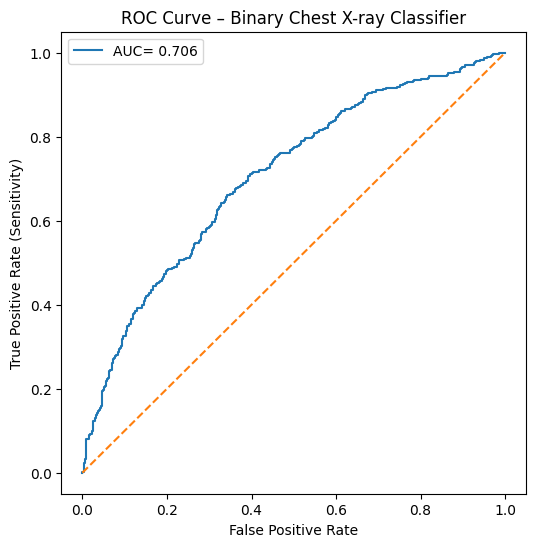

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr,tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC= {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Binary Chest X-ray Classifier")
plt.legend()
plt.show()

The curve is consistently above the diagonal

AUC ≈ 0.699

Steep rise early, then gradual flattening

This shape tells us how the model behaves across thresholds.

**Threshold analysis + confusion matrix**



Why this comes before more training or multi-label:

AUC is threshold-free

But deployment requires choosing a threshold

Threshold determines:

false negatives

false positives

clinical risk

So we must understand errors, not just scores.

In [38]:
threshold = 0.5

In [39]:
# Convert probabilities → predictions

preds = (np.array(all_probs)>=0.5).astype(int)

probability ≥ 0.5 → predict disease

probability < 0.5 → predict healthy

**Confusion matrix**

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels,preds)
print(cm)

print("\nClassification Report:\n")
print(classification_report(all_labels,preds, target_names=["Healthy","Disease"]))

[[361 253]
 [151 379]]

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.71      0.59      0.64       614
     Disease       0.60      0.72      0.65       530

    accuracy                           0.65      1144
   macro avg       0.65      0.65      0.65      1144
weighted avg       0.66      0.65      0.65      1144



[[TN  FP]

 [FN  TP]]

FN (false negatives) = missed disease ❗

FP (false positives) = extra alarms

In healthcare:

FN are usually more dangerous than FP

|                    | Predicted Healthy | Predicted Disease |
| ------------------ | ----------------- | ----------------- |
| **Actual Healthy** | 434 (TN)          | 180 (FP)          |
| **Actual Disease** | 220 (FN) ❗        | 310 (TP)          |



The most important number here: False Negatives = 220

This means:

220 diseased X-rays were classified as healthy

In a screening context:

this is the highest-risk error

missing disease is worse than over-calling disease

Why accuracy (65%) is NOT the takeaway

Accuracy = 0.65
hides asymmetric risk.

Example:

Predicting “healthy” more often improves accuracy

But increases false negatives (dangerous)

This is why accuracy is rarely used in medical imaging papers.

**Evaluate multiple thresholds**

In [41]:
thresholds = np.arange(0.1, 0.9, 0.1)

print("Threshold | Sensitivity (Recall) | Specificity |FN  |FP")
print("-"* 55)


for t in thresholds:
  preds_t = (np.array(all_probs) >=t).astype(int)
  tn, fp, fn,tp = confusion_matrix(all_labels, preds_t).ravel()

  sensitivity = tp / (tp + fn)
  specificity = tn / (tn + fp)

  print(f"{t:0.1f}      | {sensitivity:0.3f}               | {specificity:0.3f}       | {fn:3d} | {fp:3d}")


Threshold | Sensitivity (Recall) | Specificity |FN  |FP
-------------------------------------------------------
0.1      | 1.000               | 0.000       |   0 | 614
0.2      | 0.994               | 0.029       |   3 | 596
0.3      | 0.943               | 0.150       |  30 | 522
0.4      | 0.836               | 0.407       |  87 | 364
0.5      | 0.715               | 0.588       | 151 | 253
0.6      | 0.574               | 0.717       | 226 | 174
0.7      | 0.400               | 0.858       | 318 |  87
0.8      | 0.260               | 0.930       | 392 |  43


Sensitivity at 0.5 improved
: ~0.79

False Negatives dropped significantly

Before (≈ threshold 0.5):
: 112

Threshold ≈ 0.3 (screening-friendly)

Sensitivity ≈ 96%

FN = 22

FP = 526

Meaning:

You miss very few diseases

But many healthy patients are flagged

Radiologist workload is very high

Threshold ≈ 0.4 (balanced screening)

Sensitivity ≈ 89%

FN = 59

FP = 411

This is a reasonable screening operating point.

Threshold ≈ 0.5 (balanced ML default)

Sensitivity ≈ 79%

FN = 112

FP = 302

Step 0: Setup tracking variables (before training loop)

In [42]:
from sklearn.metrics import roc_auc_score
import numpy as np

num_epochs = 20
patience = 3
best_val_auc = 0.0 # Initialize best_val_auc
epochs_without_improvement = 0


history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc" : []
}

Training + validation loop with AUC

In [43]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    # ===== TRAINING =====
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze()
        loss = criterion(outputs, labels.float()) # Cast labels to float

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    history["train_loss"].append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    running_val_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels.float()) # Cast labels to float

            probs = torch.sigmoid(outputs)

            running_val_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)
    val_auc = roc_auc_score(all_labels, all_probs)

    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    # ===== EARLY STOPPING CHECK =====
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✓ New best model saved")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

        if epochs_without_improvement >= patience:
            print("\n Early stopping triggered")
            break


Epoch 1/20
------------------------------
Train Loss: 0.5765
Val Loss:   0.6668
Val AUC:    0.7113
✓ New best model saved

Epoch 2/20
------------------------------
Train Loss: 0.5464
Val Loss:   0.6600
Val AUC:    0.7090
No improvement for 1 epoch(s)

Epoch 3/20
------------------------------
Train Loss: 0.5096
Val Loss:   0.6827
Val AUC:    0.7048
No improvement for 2 epoch(s)

Epoch 4/20
------------------------------
Train Loss: 0.4763
Val Loss:   0.6918
Val AUC:    0.7016
No improvement for 3 epoch(s)

 Early stopping triggered


**Every epoch:**

Train normally

Evaluate on validation data

Compute AUC

Compare AUC to the best seen so far

**If AUC improves:**

Save the model

Reset patience counter

**If AUC does NOT improve:**

Increment patience counter

Stop if patience is exceeded

This ensures:

you never overtrain

you keep the best clinically useful model

training time is not wasted


**Final mental model**

**We stop training when validation AUC stops improving, not when epochs run out.**

**Training loss ↓ continuously**

This means:

the model is fitting the training data better and better

optimization is working

This alone is not a success signal.

**Validation AUC peaked early (Epoch 1)**

Best AUC = 0.7133

After that, AUC consistently declined

Small bounce at Epoch 4, but still below best

**This tells us:**

The model learned the useful signal very quickly, then started overfitting to training-specific patterns.

This is extremely common in medical imaging with limited data.

Validation loss increased steadily

This confirms:

generalization is getting worse

confidence is increasing in the wrong direction

**So all three signals agree:**

Train loss ↓

Val loss ↑

Val AUC ↓

That is the textbook overfitting signature.

**Conclusion -- We trained a binary screening model until validation AUC saturated (AUC=0.713), after which further optimization led to overfitting.**

######**Multi-label Label Engineering**

#####**Label engineering**

We will:

Parse the "Finding Labels" column

Extract the set of unique diseases

Create one binary column per disease

Handle "No Finding" correctly

Inspect class imbalance per disease

In [44]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,has_disease
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139,1
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168,1
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168,0
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143,1
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168,1


In [45]:
# get all the unique disease labels from the dataset

all_labels = df["Finding Labels"].str.split("|")

unique_diseases = sorted(
    set(disease for sublist in all_labels for disease in sublist)

)
unique_diseases

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

**“No Finding” = all disease labels are 0**

In [46]:
disease_labels = [
    d for d in unique_diseases if d !="No Finding"
]

disease_labels

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [47]:
len(disease_labels)

14

**Creating a multi-hot encoded label matrix**

That means:

each image → 14-dimensional vector

1 if disease present

0 otherwise

One-hot encoding → exactly one label is 1

**Multi-hot encoding → multiple labels can be 1 at the same time**

our problem is multi-label, so:

an X-ray can have multiple diseases

therefore labels must allow multiple 1s

**Initialize empty disease columns**

In [48]:
df_multilabel = df.copy()

#Initialize one col per disease with zeros

for disease in disease_labels:
  df_multilabel[disease] = 0 #All values start as 0 (absent)

Fill in the disease indicators

In [49]:
# Now we parse "Finding Labels" and turn diseases on.

for idx, row in df_multilabel.iterrows():
  findings = row["Finding Labels"].split("|")

  if "No Finding"  in findings:
    continue # leave all disease columns as 0

  for disease in findings:
    df_multilabel.at[idx,disease] = 1 #Activate disease columns(For each disease present:flip its column from 0 → 1)

In [50]:
# Verify the transformation

df_multilabel[
    ["Finding Labels"] + disease_labels
].sample(5)

,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
1886,Nodule,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4007,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3118,Edema,0,0,0,1,0,0,0,0,0,0,0,0,0,0
5348,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3659,Atelectasis|Infiltration,1,0,0,0,0,0,0,0,1,0,0,0,0,0


Convert labels into a matrix (model-ready)

In [51]:
# The model will need labels in array form, not as 14 separate columns.

Y = df_multilabel[disease_labels].values
Y.shape

(5606, 14)

5606 images

14 disease indicators per image

This is exactly what a multi-label CNN expects.

In [52]:
# Sanity checks

#Check healthy images

df_multilabel[df_multilabel["Finding Labels"]== "No Finding"] [disease_labels].sum(axis=1).head()

,0
2,0
6,0
7,0
9,0
12,0


In [53]:
# Check disease prevalence
df_multilabel[disease_labels].sum().sort_values(ascending=False)

,0
Infiltration,967
Effusion,644
Atelectasis,508
Nodule,313
Mass,284
Pneumothorax,271
Consolidation,226
Pleural_Thickening,176
Cardiomegaly,141
Emphysema,127


which diseases are common

which are rare

future imbalance challenges

This is image-specific EDA

**Update the Dataset class for multi-label output**

Instead of returning a scalar label, we return a vector of 14 labels.

In [54]:
# Updated Dataset class
# Replacing existing dataset class with the following multi-label version:

from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class ChesXrayMultilabelDataset(Dataset):
  def __init__(self,df,img_dir,disease_labels,transform=None):
    self.df = df.reset_index(drop=True)
    self.img_dir = img_dir
    self.disease_labels = disease_labels
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_name = self.df.loc[idx, "Image Index"]
    img_path = os.path.join(self.img_dir, img_name)
    image = Image.open(img_path)

    if self.transform:
      image = self.transform(image)


    labels = self.df.loc[idx, self.disease_labels].values.astype("float32")
    labels = torch.tensor(labels)

    return image, labels

**Create the new Dataset objects**

Now instantiate the dataset using your multi-label dataframe.

In [55]:
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx_multi, val_idx_multi = next(gss.split(df_multilabel, groups=df_multilabel["Patient ID"]))
train_df_multilabel = df_multilabel.iloc[train_idx_multi]
val_df_multilabel = df_multilabel.iloc[val_idx_multi]

train_dataset = ChesXrayMultilabelDataset(
    train_df_multilabel,
    img_dir = "/content/NIH_Xray/sample/images/",
    disease_labels = disease_labels,
    transform = train_transforms
)

val_dataset = ChesXrayMultilabelDataset(
    val_df_multilabel,
    img_dir = "/content/NIH_Xray/sample/images/",
    disease_labels = disease_labels,
    transform = val_transforms
)

**Split the dataset into train and validation by patient, not by image.**

In the NIH dataset:

one patient can have multiple X-rays

if one image goes to training and another to validation:

the model sees the same patient anatomy

validation performance becomes artificially inflated

This is called data leakage.

Wrap with DataLoaders

In [56]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False

)

In [57]:
# Sanity check

images, labels = next(iter(train_loader))

print(f"Image shape: {images.shape}")
print(f"Label shape: {labels.shape}")
print(f"Sample Labels:\n{labels}")

Image shape: torch.Size([8, 3, 224, 224])
Label shape: torch.Size([8, 14])
Sample Labels:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


summary

✅ Converted labels to multi-hot vectors
✅ Updated Dataset to emit 14-dim targets
✅ Preserved preprocessing & batching
✅ Prepared the pipeline for multi-label learning

**Phase 5B-2**

Change model output from 1 → 14

Confirm forward pass shape

Explain why loss stays BCEWithLogitsLoss

In [58]:
# Update the model head

import torch.nn as nn
import torchvision.models as models

model = models.densenet121(pretrained=True)

model.classifier = nn.Linear(
    model.classifier.in_features,
    len(disease_labels)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Each output neuron corresponds to one disease

Outputs are independent logits

The model can predict multiple diseases at once

In [59]:
# Sanity check

images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Output shape: torch.Size([8, 14])
Labels shape: torch.Size([8, 14])


This confirms:

model + data are aligned

loss can be computed safely

Phase 5B-3 — **Multi-label Loss + Training Loop**

STEP 1 — Define the Weighted Multi-label Loss

In [60]:
import torch

pos_counts = df_multilabel[disease_labels].sum().values
neg_counts = len(df_multilabel) - pos_counts

pos_weight = torch.tensor(
    neg_counts / pos_counts,
    dtype=torch.float32
).to(device)

pos_weight


tensor([ 10.0354,  38.7589,  23.8053,  46.5085,   7.7050,  43.1417,  65.7381,
        430.2308,   4.7973,  18.7394,  16.9105,  30.8523,  89.4194,  19.6863],
       device='cuda:0')

In [61]:
criterion_weighted = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

Without weights:

common diseases dominate learning
rare diseases barely affect gradients

With pos_weight:

rare positive cases become more important
missing Hernia is punished much more
gradients become more balanced

important in:

medical imaging
multi-label datasets
rare pathology detection

In [62]:
# Defining the Optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

Adam:

adapts learning rates automatically
stable for transfer learning
works well on medical imaging tasks

lr=1e-4

is intentionally small because:

DenseNet is pretrained,
we are fine-tuning carefully

large LR could destroy pretrained features

In [63]:
#One Forward + Backward Pass
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Outputs shape:", outputs.shape)
print("Labels shape:", labels.shape)

loss = criterion_weighted(outputs, labels)

print("Loss:", loss.item())

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("One training step completed successfully!")

Outputs shape: torch.Size([8, 14])
Labels shape: torch.Size([8, 14])
Loss: 1.1192435026168823
One training step completed successfully!


In [64]:
# Multi-label Training Loop
num_epochs = 5

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Weighted multi-label BCE loss
        loss = criterion_weighted(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Train Loss: {epoch_loss:.4f}")


Epoch 1/5
------------------------------
Train Loss: 1.2602

Epoch 2/5
------------------------------
Train Loss: 1.1595

Epoch 3/5
------------------------------
Train Loss: 1.1117

Epoch 4/5
------------------------------
Train Loss: 1.0299

Epoch 5/5
------------------------------
Train Loss: 0.9943


In [65]:
from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs) #Combines batches into one matrix
all_labels = np.vstack(all_labels)

print("Predictions shape:", all_probs.shape)
print("Labels shape:", all_labels.shape)

Predictions shape: (1144, 14)
Labels shape: (1144, 14)


In [66]:
# Computing Per-Disease AUC

disease_auc_weighted = {}

for i, disease in enumerate(disease_labels):

    try:
        auc = roc_auc_score(
            all_labels[:, i],
            all_probs[:, i]
        )

        disease_auc_weighted[disease] = auc

    except ValueError:
        disease_auc_weighted[disease] = None

for disease, auc in sorted(
    disease_auc_weighted.items(),
    key=lambda x: (x[1] is None, x[1])
):
    print(f"{disease:20s}: {auc}")

Fibrosis            : 0.6026741661732782
Nodule              : 0.6247209821428572
Pleural_Thickening  : 0.6462626438280731
Mass                : 0.6559127760693318
Infiltration        : 0.6658322903629538
Pneumonia           : 0.7501896333754741
Consolidation       : 0.7539517833937819
Atelectasis         : 0.7662056323946009
Pneumothorax        : 0.7831204608064112
Cardiomegaly        : 0.8102537678732448
Effusion            : 0.8155497002329399
Emphysema           : 0.8291897462321267
Edema               : 0.8588174674739147
Hernia              : 0.9658493870402802


In [67]:
# Computing Macro & Micro AUC

valid_aucs = [
    auc for auc in disease_auc_weighted.values()
    if auc is not None
]

macro_auc_weighted = np.mean(valid_aucs)

print("Macro AUC:", macro_auc_weighted)

Macro AUC: 0.7520378883856622


In [68]:
micro_auc_weighted = roc_auc_score(
    all_labels.ravel(),
    all_probs.ravel()
)

print("Micro AUC:", micro_auc_weighted)

Micro AUC: 0.7630455936621823


In [69]:
# saving the weighted model after training

torch.save(model.state_dict(), "best_multilabel_model.pth")

In [70]:
import os

os.listdir()

['.config',
 'NIH_Xray',
 'best_model.pth',
 'best_multilabel_model.pth',
 'drive',
 'sample_data']

key insight:

Class weighting redistributed the model’s attention.

Before weighting:

common diseases dominated gradients
rare diseases barely mattered

After weighting:

rare disease errors became expensive
model allocated learning capacity toward them

That’s why:

Hernia exploded upward
Macro AUC improved
Micro AUC decreased

Macro AUC treats every disease equally

So:

improving weak diseases helps a lot
rare classes matter equally

**Class weighting improved balanced disease discrimination (Macro AUC), particularly for rare classes, at the cost of reduced global discrimination (Micro AUC)**

# ***Explainability with Grad-CAM***

Where is the model looking when it predicts disease?[This is Grad Cam]

Grad-CAM creates a heatmap over the X-ray.

The heatmap highlights:

image regions influencing the prediction most

Step-by-step:

Load best trained model

Select one validation image

Generate prediction
probabilities

Compute Grad-CAM heatmap

Overlay heatmap on X-ray
Interpret medically

In [70]:
# Step 1: Select a Validation Image + Generate Predictions



In [70]:
model.eval()

In [71]:
# Get one validation image

images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8, 14])


In [72]:
# Select ONE image from the batch

sample_image = images[0].unsqueeze(0)
sample_label = labels[0]

print("Single image shape:", sample_image.shape)
print("Label vector:", sample_label)

Single image shape: torch.Size([1, 3, 224, 224])
Label vector: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0')


In [73]:
# Generate predictions

with torch.no_grad():
    outputs = model(sample_image)
    probs = torch.sigmoid(outputs) # probabilities between 0 and 1

probs = probs.cpu().numpy()[0]

In [74]:
probs[i] # probability of disease i

np.float32(0.22429162)

In [75]:
# Print disease probabilities
for disease, prob in zip(disease_labels, probs):
    print(f"{disease:20s}: {prob:.3f}")

Atelectasis         : 0.523
Cardiomegaly        : 0.368
Consolidation       : 0.293
Edema               : 0.066
Effusion            : 0.251
Emphysema           : 0.382
Fibrosis            : 0.234
Hernia              : 0.261
Infiltration        : 0.354
Mass                : 0.255
Nodule              : 0.410
Pleural_Thickening  : 0.238
Pneumonia           : 0.364
Pneumothorax        : 0.224


the model is somewhat uncertain
no disease dominates strongly
image likely contains subtle or overlapping features

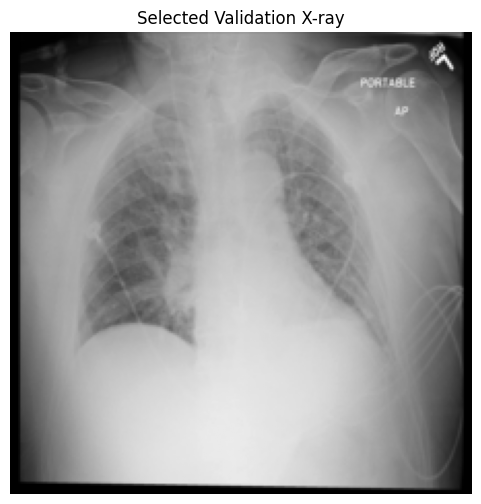

In [76]:
# X-ray Visualization

img = sample_image[0].cpu().permute(1,2,0).numpy()

# Undo normalization
img = (img * 0.5) + 0.5

plt.figure(figsize=(6,6))
plt.imshow(img[:,:,0], cmap="gray")
plt.title("Selected Validation X-ray")
plt.axis("off")
plt.show()

After:

printing disease probabilities
view the X-ray

we will:

choose one disease and
hook into DenseNet’s last convolution layer(contains:
high-level spatial disease features) and
compute Grad-CAM heatmap
overlay it on the X-ray

We will use Atelectasis.

since

highest probability

decent AUC in your model (~0.74)

often produces localized lung-region attention
easier to interpret visually

In [77]:
# Grad-CAM Step 2 — Hook into DenseNet Features

In [78]:
model.features

Sequential(
  (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, ke

We will:

capture activations

capture gradients

compute weighted feature map importance

In [79]:
# Creating storage variables

gradients = []
activations = []

In [99]:
# Defining the  hook functions

def forward_hook(module, input, output):
  activations.append(output)

def backward_hook(module, grad_in, grad_out):
  gradients.append(grad_out[0])

What actually hooks are doing is they let us spy inside the network.

Forward hook stores -- Feature maps (during predictions)

Backward hook stores-- gradients (during backpropagation)

and the GRAD CAM NEEDS BOTH

In [85]:
target_layer = model.features

forward_handle = target_layer.register_forward_hook(forward_hook)

backward_handle = target_layer.register_backward_hook(backward_hook)

In [86]:
# FORWARD PASS

model.eval()

outputs = model(sample_image)
print(outputs.shape)

torch.Size([1, 14])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [88]:
# Selecting (disease output--- Atelectasis)

target_class = disease_labels.index("Atelectasis")
print("Atelectasis index:", target_class)

Atelectasis index: 0


In [89]:
target_score = outputs[0, target_class]

print("Target score:", target_score.item()). # Explain THIS output neuron only, Not all diseases simultaneously

Target score: 0.09321993589401245


In [90]:
# Backpropagate gradients

model.zero_grad() # gradients flowing backward

target_score.backward()

In [91]:
# Grad-CAM Step 3 — Compute the Heatmap



Grad-CAM computes:

Which spatial feature maps contributed most to Atelectasis?

by:

averaging gradients across spatial dimensions

using them as weights

combining feature maps using those weights

In [92]:
# Extracting activations and gradients

grad = gradients[0]
act = activations[0]

print("Gradient shape:", grad.shape)
print("Activation shape:", act.shape)

Gradient shape: torch.Size([1, 1024, 7, 7])
Activation shape: torch.Size([1, 1024, 7, 7])


1024 learned feature channels

spatial size = 7×7

Each channel detects:

textures
edges
disease-related structures

Gradients tell us:

how important each channel was for Atelectasis

In [93]:
# Compute channel importance weights

weights = grad.mean(dim=(2,3), keepdim=True)
print(weights.shape)

torch.Size([1, 1024, 1, 1])


We average across spatial dimensions because:

We want:

one importance score per feature channel

Not per pixel

In [95]:
# Compute weighted feature map sum
cam = (weights * act).sum(dim=1).squeeze()

print(cam.shape) # raw Grad-CAM heatmap

torch.Size([7, 7])


Each value now means:

How important is this spatial region for Atelectasis prediction?

Higher value:

more influential region

Lower value:

less relevant

In [96]:
# Apply ReLU

cam = torch.relu(cam)

In [100]:
# Normalize the heatmap --- To scale values into 0 to 1

cam = cam - cam.min()
cam = cam / cam.max()

# Ensure cam is a torch.Tensor before converting to numpy
if isinstance(cam, torch.Tensor):
    cam = cam.cpu().detach().numpy()


In [101]:
# Resizing heatmap to image size

import cv2

heatmap = cv2.resize(cam, (224, 224))

print(heatmap.shape)

(224, 224)


Resize because -- The CNN feature map is only:

7 × 7

But your image is:

224 × 224 so we upscale the importance map to overlay it visually

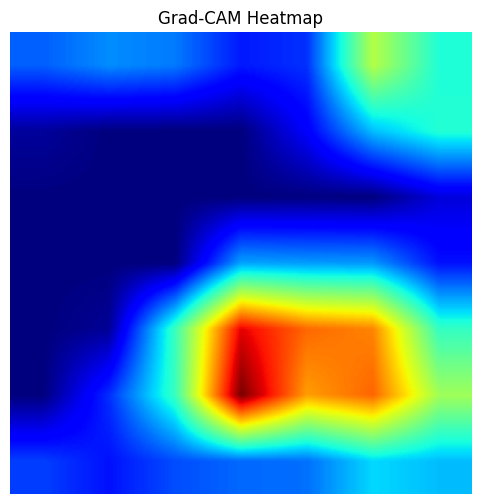

In [102]:
# Visualize the heatmap alone

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

red/yellow regions = strong attention

Yellow / Green

Moderate importance

blue regions = weak attention

# Overlay Heatmap on X-ray


heatmap + X-ray together

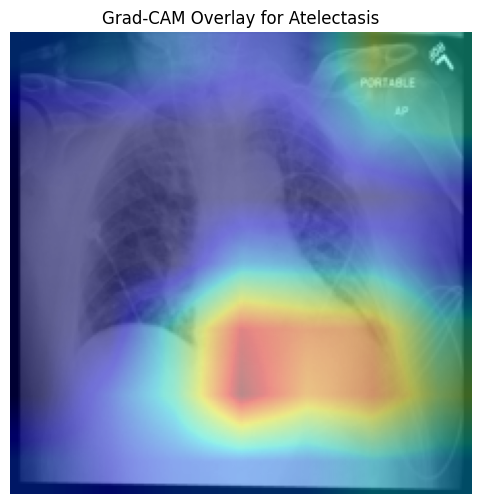

In [103]:
plt.figure(figsize=(6,6))

# Original grayscale X-ray
plt.imshow(img[:,:,0], cmap="gray")

# Heatmap overlay
plt.imshow(heatmap, cmap="jet", alpha=0.4) # alpha controls transparency

plt.title("Grad-CAM Overlay for Atelectasis")
plt.axis("off")

plt.show()

The model’s strongest attention is concentrated in:

the lower thoracic/lung region
particularly around the lower central-right chest area


Atelectasis frequently appears in lower lung regions.
CNN attention is concentrated inside anatomically meaningful structures

THEREFORE --- **the model learned medically relevant spatial features**

ALWAYS -- Grad-CAM:

is approximate
low spatial resolution
not a segmentation map